<a href="https://colab.research.google.com/github/mauliasugeha/StudyCase-KAL-Klasifikasi/blob/main/Klasifikasi_Diabetes_KI7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Import library yang diperlukan
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import accuracy_score, classification_report

In [ ]:
!wget https://github.com/npradaschnor/Pima-Indians-Diabetes-Dataset/blob/master/diabetes.csv

--2025-04-27 09:59:07--  https://github.com/npradaschnor/Pima-Indians-Diabetes-Dataset/blob/master/diabetes.csv
Resolving github.com (github.com)... 140.82.114.4
Connecting to github.com (github.com)|140.82.114.4|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: unspecified [text/html]
Saving to: ‘diabetes.csv’

diabetes.csv            [ <=>                ] 246.93K  --.-KB/s    in 0.06s   

2025-04-27 09:59:07 (3.79 MB/s) - ‘diabetes.csv’ saved [252858]



In [ ]:
# Baca dataset langsung dari GitHub
url = 'https://raw.githubusercontent.com/npradaschnor/Pima-Indians-Diabetes-Dataset/master/diabetes.csv'
df = pd.read_csv(url)

In [ ]:
# Tampilkan data
print(df)

     Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0              6      148             72             35        0  33.6   
1              1       85             66             29        0  26.6   
2              8      183             64              0        0  23.3   
3              1       89             66             23       94  28.1   
4              0      137             40             35      168  43.1   
..           ...      ...            ...            ...      ...   ...   
763           10      101             76             48      180  32.9   
764            2      122             70             27        0  36.8   
765            5      121             72             23      112  26.2   
766            1      126             60              0        0  30.1   
767            1       93             70             31        0  30.4   

     DiabetesPedigreeFunction  Age  Outcome  
0                       0.627   50        1  
1                  

In [ ]:
# Pisahkan fitur dan label
X = df.drop('Outcome', axis=1)
y = df['Outcome']

In [ ]:
# Bagi data menjadi data latih dan data uji
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [ ]:
# Normalisasi data menggunakan MinMaxScaler agar rentangnya berada di [0, 1]
scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
print(df)

     Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0              6      148             72             35        0  33.6   
1              1       85             66             29        0  26.6   
2              8      183             64              0        0  23.3   
3              1       89             66             23       94  28.1   
4              0      137             40             35      168  43.1   
..           ...      ...            ...            ...      ...   ...   
763           10      101             76             48      180  32.9   
764            2      122             70             27        0  36.8   
765            5      121             72             23      112  26.2   
766            1      126             60              0        0  30.1   
767            1       93             70             31        0  30.4   

     DiabetesPedigreeFunction  Age  Outcome  
0                       0.627   50        1  
1                  

In [ ]:
# Import dan latih model Logistic Regression
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print(y_pred) #print hasil prediksi masing-masing pasien (1 = diabetes, 0 = tidak)

[0 0 0 0 0 0 0 0 1 1 0 1 0 0 0 0 0 0 1 0 0 0 0 0 1 1 0 0 0 0 1 1 1 1 1 1 1
 0 1 0 0 1 1 0 0 1 1 0 0 1 0 1 1 0 0 0 1 0 0 1 1 0 0 0 0 0 0 1 0 1 1 0 0 0
 0 1 0 0 0 0 1 0 0 0 0 1 1 0 0 0 0 0 0 0 0 0 0 0 1 0 1 0 1 0 1 0 0 1 0 0 0
 0 0 1 0 0 1 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 0 0 1 0 0 1 1 0 0 0 0 0 0 0 0 0
 0 1 0 0 0 0 0 0 0 1 1 0 0 1 0 0 0 1 0 0 1 0 1 0 0 1 1 0 0 0 0 0 1 1 0 1 1
 0 0 0 1 0 0 0 1 0 0 0 0 0 0 1 0 0 0 0 1 0 0 0 1 1 0 0 0 0 1 0 1 0 0 1 1 0
 0 0 0 0 0 0 0 0 0]


In [ ]:
#Evaluasi hasil prediksi
from sklearn.metrics import accuracy_score, classification_report
print("Akurasi:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Akurasi: 0.7445887445887446
              precision    recall  f1-score   support

           0       0.78      0.84      0.81       151
           1       0.65      0.56      0.60        80

    accuracy                           0.74       231
   macro avg       0.72      0.70      0.71       231
weighted avg       0.74      0.74      0.74       231



### **Klasifikasi Diabetes dengan Penambahan Noise (Laplace Mechanism)**

In [ ]:
# Install diffprivlib (jalankan hanya sekali di Google Colab)
!pip install diffprivlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 176.9/176.9 kB 3.3 MB/s eta 0:00:00


In [ ]:
# Import library yang diperlukan
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [ ]:
# Baca dataset langsung dari GitHub
url = 'https://raw.githubusercontent.com/npradaschnor/Pima-Indians-Diabetes-Dataset/master/diabetes.csv'
df = pd.read_csv(url)

In [ ]:
# Tampilkan data
print(df)

     Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0              6      148             72             35        0  33.6   
1              1       85             66             29        0  26.6   
2              8      183             64              0        0  23.3   
3              1       89             66             23       94  28.1   
4              0      137             40             35      168  43.1   
..           ...      ...            ...            ...      ...   ...   
763           10      101             76             48      180  32.9   
764            2      122             70             27        0  36.8   
765            5      121             72             23      112  26.2   
766            1      126             60              0        0  30.1   
767            1       93             70             31        0  30.4   

     DiabetesPedigreeFunction  Age  Outcome  
0                       0.627   50        1  
1                  

In [ ]:
# Pisahkan fitur dan label
X = df.drop('Outcome', axis=1)
y = df['Outcome']

In [ ]:
# Bagi data menjadi data latih dan data uji
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [ ]:
# Normalisasi data menggunakan MinMaxScaler agar rentangnya berada di [0, 1]
scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
print(df)

     Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0              6      148             72             35        0  33.6   
1              1       85             66             29        0  26.6   
2              8      183             64              0        0  23.3   
3              1       89             66             23       94  28.1   
4              0      137             40             35      168  43.1   
..           ...      ...            ...            ...      ...   ...   
763           10      101             76             48      180  32.9   
764            2      122             70             27        0  36.8   
765            5      121             72             23      112  26.2   
766            1      126             60              0        0  30.1   
767            1       93             70             31        0  30.4   

     DiabetesPedigreeFunction  Age  Outcome  
0                       0.627   50        1  
1                  

In [ ]:
# Import Laplace Mechanism dari diffprivlib
from diffprivlib.mechanisms import Laplace

In [ ]:
# Salin data dan siapkan mekanisme Laplace
X_noisy = X_train.copy()
lap = Laplace(epsilon=1.0, sensitivity=1.0)

In [ ]:
import numpy as np
X_noisy_df = pd.DataFrame(X_noisy)

In [ ]:
# Tambahkan noise Laplace ke setiap fitur
for col in X_noisy_df.columns:
  X_noisy_df[col] = X_noisy_df[col].apply(lambda x: x + lap.randomise(x))

In [ ]:
#Menampilkan Data Sebelum dan Sesudah Diberi Noise:
#Tampilkan 5 baris pertama data asli
print("Sebelum (5 baris):")
X_train_df = pd.DataFrame(X_train)
X_train_df.columns = ['Pregnancies', 'Glucose', 'BloodPressure','SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']
X_train_df.head()

Sebelum (5 baris):


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,0.058824,0.477387,0.491803,0.285714,0.068558,0.356185,0.077711,0.016667
1,0.294118,0.527638,0.590164,0.460317,0.384161,0.549925,0.034586,0.116667
2,0.000000,0.678392,0.557377,0.666667,0.295508,0.630402,0.122545,0.050000
3,0.235294,0.658291,0.557377,0.333333,0.196217,0.493294,0.035013,0.116667
4,0.058824,0.517588,0.245902,0.603175,0.098109,0.645306,0.044833,0.200000


In [ ]:
# Tampilkan 5 baris pertama data yang sudah diberi noise
print("\nSesudah (5 baris):")
X_noisy_df.columns = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']
X_noisy_df.head()


Sesudah (5 baris):


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,1.422343,3.011841,3.355019,-0.789178,1.626684,0.192870,-0.703350,-0.416786
1,-0.332164,2.250577,0.949306,0.945913,4.632093,-0.236930,0.147107,0.145641
2,0.428041,1.480043,1.543664,1.401769,1.783616,0.367166,2.240862,-0.429392
3,0.563445,3.301836,1.346025,-0.581353,0.099908,2.579145,1.293466,0.836105
4,-1.010217,1.269585,0.878130,2.226318,0.250280,0.146805,0.241281,0.820631


In [ ]:
# Latih model dengan data yang sudah diberi noise
model_noise = LogisticRegression(max_iter=1000)
model_noise.fit(X_noisy_df, y_train)
y_pred_noise = model_noise.predict(X_test)

/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


In [ ]:
# Evaluasi hasil prediksi
print("Akurasi dengan noise:", accuracy_score(y_test, y_pred_noise))
print(classification_report(y_test, y_pred_noise))

Akurasi dengan noise: 0.6536796536796536
              precision    recall  f1-score   support

           0       0.65      1.00      0.79       151
           1       0.00      0.00      0.00        80

    accuracy                           0.65       231
   macro avg       0.33      0.50      0.40       231
weighted avg       0.43      0.65      0.52       231



/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


### **Klasifikasi Diabetes dengan DP Logistic Regression dari diffprivlib**


In [ ]:
# Import library yang diperlukan
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [ ]:
# Baca dataset langsung dari GitHub
url = 'https://raw.githubusercontent.com/npradaschnor/Pima-Indians-Diabetes-Dataset/master/diabetes.csv'
df = pd.read_csv(url)

In [ ]:
# Tampilkan data
print(df)

     Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0              6      148             72             35        0  33.6   
1              1       85             66             29        0  26.6   
2              8      183             64              0        0  23.3   
3              1       89             66             23       94  28.1   
4              0      137             40             35      168  43.1   
..           ...      ...            ...            ...      ...   ...   
763           10      101             76             48      180  32.9   
764            2      122             70             27        0  36.8   
765            5      121             72             23      112  26.2   
766            1      126             60              0        0  30.1   
767            1       93             70             31        0  30.4   

     DiabetesPedigreeFunction  Age  Outcome  
0                       0.627   50        1  
1                  

In [ ]:
# Pisahkan fitur dan label
X = df.drop('Outcome', axis=1)
y = df['Outcome']

In [ ]:
# Bagi data menjadi data latih dan data uji
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [ ]:
# Normalisasi data menggunakan MinMaxScaler agar rentangnya berada di [0, 1]
scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
# Import Logistic Regression versi DP dari diffprivlib
from diffprivlib.models import LogisticRegression as DPLogisticRegression

In [ ]:
#Klasifikasi dan Evaluasi
# Hitung data_norm maksimum
norms = np.linalg.norm(X_train, axis=1)
max_norm = np.max(norms)

In [ ]:
#Inisialisasi model dengan nilai data_norm
dp_model = DPLogisticRegression(epsilon=1.0, data_norm=max_norm)

In [ ]:
# Latih model Logistic Regression dengan Differential Privacy
dp_model.fit(X_train, y_train)
y_pred_dp = dp_model.predict(X_test)

In [ ]:
# Evaluasi hasil prediksi model DP
print("Akurasi dengan DP Logistic Regression:", accuracy_score(y_test,y_pred_dp))
print(classification_report(y_test, y_pred_dp))

Akurasi dengan DP Logistic Regression: 0.329004329004329
              precision    recall  f1-score   support

           0       0.48      0.28      0.36       151
           1       0.23      0.41      0.30        80

    accuracy                           0.33       231
   macro avg       0.36      0.35      0.33       231
weighted avg       0.39      0.33      0.34       231



In [ ]:
# Evaluasi akurasi model terhadap berbagai nilai epsilon
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler

epsilons = np.logspace(-2, 2, 50)
accuracy = []

for eps in epsilons:
  dp_model = DPLogisticRegression(epsilon=eps, data_norm=max_norm)
  dp_model.fit(X_train, y_train)
  acc = dp_model.score(X_test, y_test)
  accuracy.append(acc)

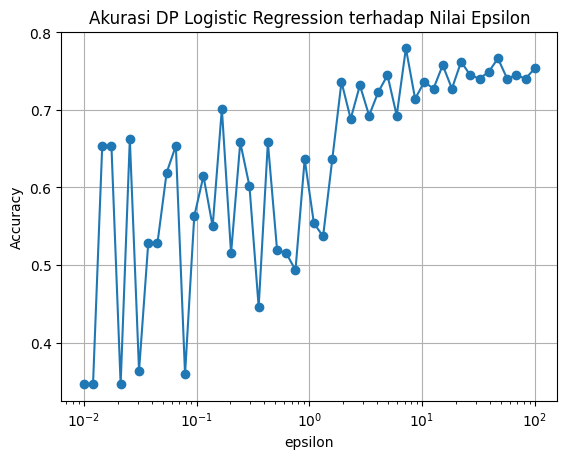

In [ ]:
# Visualisasi hasil
plt.semilogx(epsilons, accuracy, marker='o')
plt.title("Akurasi DP Logistic Regression terhadap Nilai Epsilon")
plt.xlabel("epsilon")
plt.ylabel("Accuracy")
plt.grid(True)
plt.show()